### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

import warnings
warnings.filterwarnings('ignore')

# Fix the random seeds so results are reproducible
np.random.seed(42)
tf.random.set_seed(42)

## 1. Baseline Recap

In [2]:
# Load the dataset
df = pd.read_csv('lung_cancer.csv')
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset: 5000 rows, 30 columns


In [3]:
# Feature selection: keep features with absolute correlation >= 0.05 with the target
correlations = df.corr()['lung_cancer_risk'].drop('lung_cancer_risk').abs()
baseline_features = correlations[correlations >= 0.05].index.tolist()

X = df[baseline_features]
y = df['lung_cancer_risk']

# Continuous features that need scaling
continuous_cols = ['age', 'education_years', 'smoking_years', 'cigarettes_per_day', 'pack_years',
                   'air_pollution_index', 'bmi', 'oxygen_saturation', 'fev1_x10', 'crp_level',
                   'exercise_hours_per_week', 'alcohol_units_per_week']
continuous_cols = [c for c in continuous_cols if c in X.columns]

# Scale continuous features
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[continuous_cols] = scaler.fit_transform(X[continuous_cols])

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Training set: (4000, 14), Test set: (1000, 14)


In [4]:
# Train baseline KNN (k=5) and evaluate
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train, y_train)
y_pred_base = knn_base.predict(X_test)

baseline_knn = {
    'Accuracy':  accuracy_score(y_test, y_pred_base),
    'Precision': precision_score(y_test, y_pred_base),
    'Recall':    recall_score(y_test, y_pred_base),
    'F1-Score':  f1_score(y_test, y_pred_base)
}
print("Baseline KNN (k=5):")
for m, v in baseline_knn.items():
    print(f"  {m}: {v:.4f}")

Baseline KNN (k=5):
  Accuracy: 0.9590
  Precision: 0.9407
  Recall: 0.8916
  F1-Score: 0.9155


## 2. Feature Engineering

We create three new features from the existing columns to give the models more informative signals:

- **smoking_burden**: pack-years increased when the patient is also exposed to passive smoking.
- **respiratory_symptoms**: a count (0 to 3) of the strongest respiratory indicators (COPD, chronic cough, abnormal X-ray).
- **lung_function_age**: lung function (FEV1) relative to age, capturing lung decline better than either variable alone.

In [5]:
# Create the engineered features
df['smoking_burden'] = df['pack_years'] * (1 + df['passive_smoking'])
df['respiratory_symptoms'] = df['copd'] + df['chronic_cough'] + df['xray_abnormal']
df['lung_function_age'] = df['fev1_x10'] / df['age']

# Check their correlation with the target
new_features = ['smoking_burden', 'respiratory_symptoms', 'lung_function_age']
print("Correlation of new features with lung_cancer_risk:")
print(df[new_features + ['lung_cancer_risk']].corr()['lung_cancer_risk'].drop('lung_cancer_risk').round(3))

Correlation of new features with lung_cancer_risk:
smoking_burden          0.776
respiratory_symptoms    0.820
lung_function_age      -0.466
Name: lung_cancer_risk, dtype: float64


## 3. Handling Class Imbalance (SMOTE)

The dataset is imbalanced (about 75% low risk, 25% high risk). SMOTE (Synthetic Minority Over-sampling Technique) creates new synthetic high-risk records so the training data is balanced. It is applied to the **training set only**, so the test set still reflects the real class distribution.

In [6]:
# Rebuild the feature set including the engineered features
enhanced_features = correlations[correlations >= 0.05].index.tolist()

# Recompute correlations so the new features can be selected too
correlations_new = df.corr()['lung_cancer_risk'].drop('lung_cancer_risk').abs()
enhanced_features = correlations_new[correlations_new >= 0.05].index.tolist()

X_enh = df[enhanced_features]
y_enh = df['lung_cancer_risk']

# Scale continuous features (now including the continuous engineered ones)
continuous_enh = continuous_cols + ['smoking_burden', 'lung_function_age', 'respiratory_symptoms']
continuous_enh = [c for c in continuous_enh if c in X_enh.columns]

scaler_enh = StandardScaler()
X_enh_scaled = X_enh.copy()
X_enh_scaled[continuous_enh] = scaler_enh.fit_transform(X_enh[continuous_enh])

# Split first, then balance only the training set
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_enh_scaled, y_enh, test_size=0.2, random_state=42, stratify=y_enh)

print("Before SMOTE:", y_train_e.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_e, y_train_e)

print("After SMOTE :", y_train_bal.value_counts().to_dict())

Before SMOTE: {0: 3005, 1: 995}
After SMOTE : {0: 3005, 1: 3005}


## 4. Cross-Validation

Instead of trusting a single train-test split, we use stratified 5-fold cross-validation on the balanced training data to choose the best value of k for KNN. Each k is tested on 5 different validation folds and the scores are averaged, giving a more reliable estimate.

Best k (highest cross-validated recall): 1


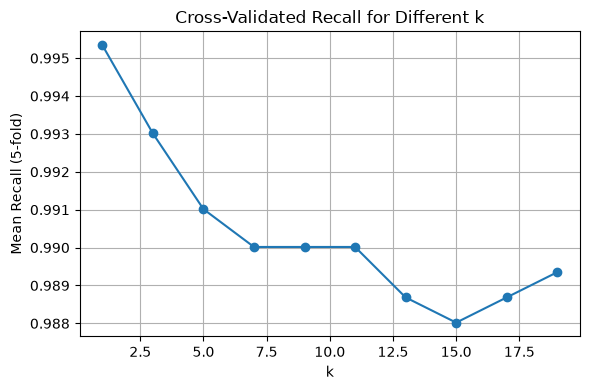

In [7]:
# Use stratified 5-fold cross-validation to find the best k
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

k_values = range(1, 21, 2)
cv_scores = []
for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_k, X_train_bal, y_train_bal, cv=cv, scoring='recall')
    cv_scores.append(scores.mean())

best_k = list(k_values)[cv_scores.index(max(cv_scores))]
print(f"Best k (highest cross-validated recall): {best_k}")

# Plot k vs cross-validated recall
plt.figure(figsize=(6, 4))
plt.plot(list(k_values), cv_scores, marker='o')
plt.title('Cross-Validated Recall for Different k')
plt.xlabel('k')
plt.ylabel('Mean Recall (5-fold)')
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Train the Enhanced Models

In [8]:
# Enhanced KNN
knn_enh = KNeighborsClassifier(n_neighbors=best_k)
knn_enh.fit(X_train_bal, y_train_bal)
y_pred_knn_enh = knn_enh.predict(X_test_e)

enhanced_knn = {
    'Accuracy':  accuracy_score(y_test_e, y_pred_knn_enh),
    'Precision': precision_score(y_test_e, y_pred_knn_enh),
    'Recall':    recall_score(y_test_e, y_pred_knn_enh),
    'F1-Score':  f1_score(y_test_e, y_pred_knn_enh)
}
print(f"Enhanced KNN (k={best_k}):")
for m, v in enhanced_knn.items():
    print(f"  {m}: {v:.4f}")

Enhanced KNN (k=1):
  Accuracy: 0.9600
  Precision: 0.9098
  Recall: 0.9317
  F1-Score: 0.9206


In [9]:
# Enhanced ANN (same architecture as the baseline, trained on balanced data)
model = Sequential()
model.add(Input(shape=(X_train_bal.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train_bal, y_train_bal, epochs=30, validation_split=0.2, verbose=0)

y_pred_prob = model.predict(X_test_e, verbose=0)
y_pred_ann_enh = (y_pred_prob >= 0.5).astype(int)

enhanced_ann = {
    'Accuracy':  accuracy_score(y_test_e, y_pred_ann_enh),
    'Precision': precision_score(y_test_e, y_pred_ann_enh),
    'Recall':    recall_score(y_test_e, y_pred_ann_enh),
    'F1-Score':  f1_score(y_test_e, y_pred_ann_enh)
}
print("Enhanced ANN:")
for m, v in enhanced_ann.items():
    print(f"  {m}: {v:.4f}")

Enhanced ANN:
  Accuracy: 0.9740
  Precision: 0.9551
  Recall: 0.9398
  F1-Score: 0.9474


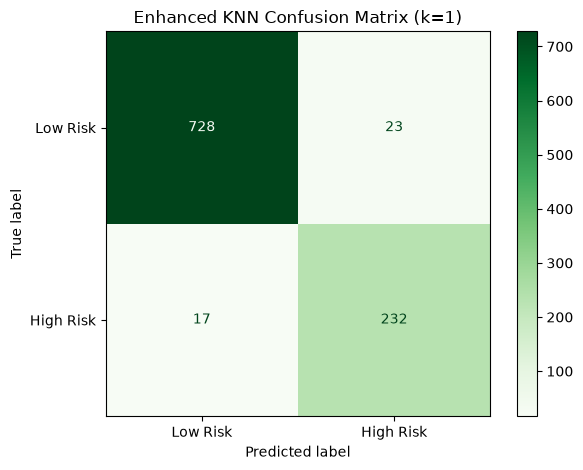

In [10]:
# Confusion matrix of the enhanced KNN
cm = confusion_matrix(y_test_e, y_pred_knn_enh)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Risk', 'High Risk'])
disp.plot(cmap='Greens')
plt.title(f'Enhanced KNN Confusion Matrix (k={best_k})')
plt.tight_layout()
plt.show()

## 6. Baseline vs Enhanced Comparison

In [11]:
# Build a comparison table
comparison = pd.DataFrame({
    'Baseline KNN':  baseline_knn,
    'Enhanced KNN':  enhanced_knn,
    'Enhanced ANN':  enhanced_ann
}).round(4)
comparison

,Baseline KNN,Enhanced KNN,Enhanced ANN
Accuracy,0.9590,0.9600,0.9740
Precision,0.9407,0.9098,0.9551
Recall,0.8916,0.9317,0.9398
F1-Score,0.9155,0.9206,0.9474


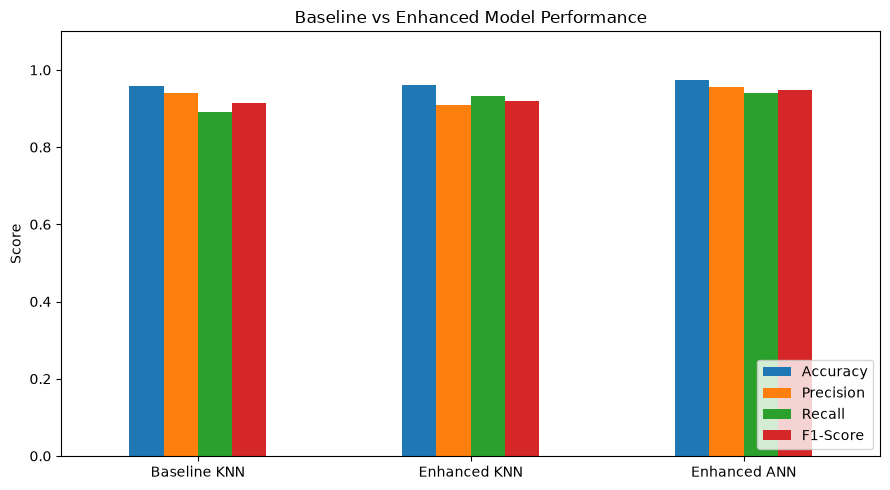

In [12]:
# Bar chart comparison
comparison.T.plot(kind='bar', figsize=(9, 5))
plt.title('Baseline vs Enhanced Model Performance')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()